# NPU 16×16 GEMM — Verilator Sim Visualization

**보드 없이 로컬에서 실행** — Verilator 시뮬레이션 결과를 파싱하여 16×16 NPU 출력을 시각화합니다.

### 데이터 소스
- **Verilator RTL 시뮬레이션** (`make sim-system`) → `[DRAIN_CSV]` 로그 파싱
- **NumPy 소프트웨어 골든** — 동일한 입력으로 Python 행렬곱
- **Systolic Array 내부 시뮬레이션** — Python으로 weight-stationary 데이터플로우 재현

```
  Weight Matrix (16×16, all 10)   Activation Matrix (16×16, lane index)
  ┌─────────────────────┐        ┌─────────────────────────────┐
  │10 10 10 ...10 10 10 │        │ 0  1  2  3  ... 13 14 15   │
  │10 10 10 ...10 10 10 │   ×    │ 0  1  2  3  ... 13 14 15   │
  │ ...                  │        │ ...                         │
  │10 10 10 ...10 10 10 │        │ 0  1  2  3  ... 13 14 15   │
  └─────────────────────┘        └─────────────────────────────┘
  Expected: psum[i][j] = Σ(act[k] × weight) = Σ(k × 10) = 10×(0+1+...+15) = 1200
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import subprocess, re, os, sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:/projects/silicontoai")
print(f"Project root: {PROJECT_ROOT}")
print(f"NumPy {np.__version__}, Matplotlib {plt.matplotlib.__version__}")

Project root: C:\projects\silicontoai
NumPy 2.4.4, Matplotlib 3.10.8


## 1. Verilator RTL 시뮬레이션 실행 & 결과 파싱

In [2]:
# Run Verilator sim via WSL and capture DRAIN_CSV output
print("Running Verilator system simulation...")
result = subprocess.run(
    ["wsl", "bash", "-c",
     "cd /mnt/c/projects/silicontoai && make sim-system 2>&1"],
    capture_output=True, text=True, timeout=120
)

# Parse [DRAIN_CSV] lines → 16×16 matrix
hw_matrix = np.zeros((16, 16), dtype=np.int32)
csv_lines = [l for l in result.stdout.splitlines() if "[DRAIN_CSV]" in l]

for line in csv_lines:
    # Format: [t=322] [DRAIN_CSV] 0,1200,1200,...
    m = re.search(r'\[DRAIN_CSV\]\s*(.+)', line)
    if m:
        parts = [int(x) for x in m.group(1).split(',')]
        row = parts[0]
        hw_matrix[row, :] = parts[1:17]

sim_passed = "SYSTEM REPLAY PASS" in result.stdout
print(f"Sim result: {'PASS ✅' if sim_passed else 'FAIL ❌'}")
print(f"Parsed {len(csv_lines)} drain rows from RTL simulation")
print(f"HW output range: [{hw_matrix.min()}, {hw_matrix.max()}]")

Running Verilator system simulation...
Sim result: PASS ✅
Parsed 16 drain rows from RTL simulation
HW output range: [1200, 1200]


## 2. NumPy 소프트웨어 골든 계산

In [3]:
# Same test data as system_reference workload:
# Weight: all 10s (int8), Activation: byte[lane] = lane (int8)
W = np.full((16, 16), 10, dtype=np.int8)     # 16×16, all 10
A = np.tile(np.arange(16, dtype=np.int8), (16, 1))  # each row = [0,1,...,15]

# GEMM: int32 accumulation (matches HW MAC behavior)
sw_matrix = (W.astype(np.int32) @ A.astype(np.int32).T)

print("Weight matrix (W):")
print(W[:4, :8], "  ... (all 10s)")
print(f"\nActivation matrix (A):")
print(A[:4, :], "  ... (each row = lane index)")
print(f"\nExpected output (W @ A^T):")
print(sw_matrix[:4, :8], f"  ... (all should be {sw_matrix[0,0]})")

Weight matrix (W):
[[10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]
 [10 10 10 10 10 10 10 10]]   ... (all 10s)

Activation matrix (A):
[[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]]   ... (each row = lane index)

Expected output (W @ A^T):
[[1200 1200 1200 1200 1200 1200 1200 1200]
 [1200 1200 1200 1200 1200 1200 1200 1200]
 [1200 1200 1200 1200 1200 1200 1200 1200]
 [1200 1200 1200 1200 1200 1200 1200 1200]]   ... (all should be 1200)


## 3. 🔥 16×16 Output Heatmap — Hardware vs Software

C:\Users\신민석\AppData\Local\Temp\ipykernel_11832\3794079091.py:41: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\신민석\AppData\Local\Temp\ipykernel_11832\3794079091.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / "docs" / "npu_gemm_heatmap.png", dpi=150, bbox_inches="tight")
c:\projects\silicontoai\.venv312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


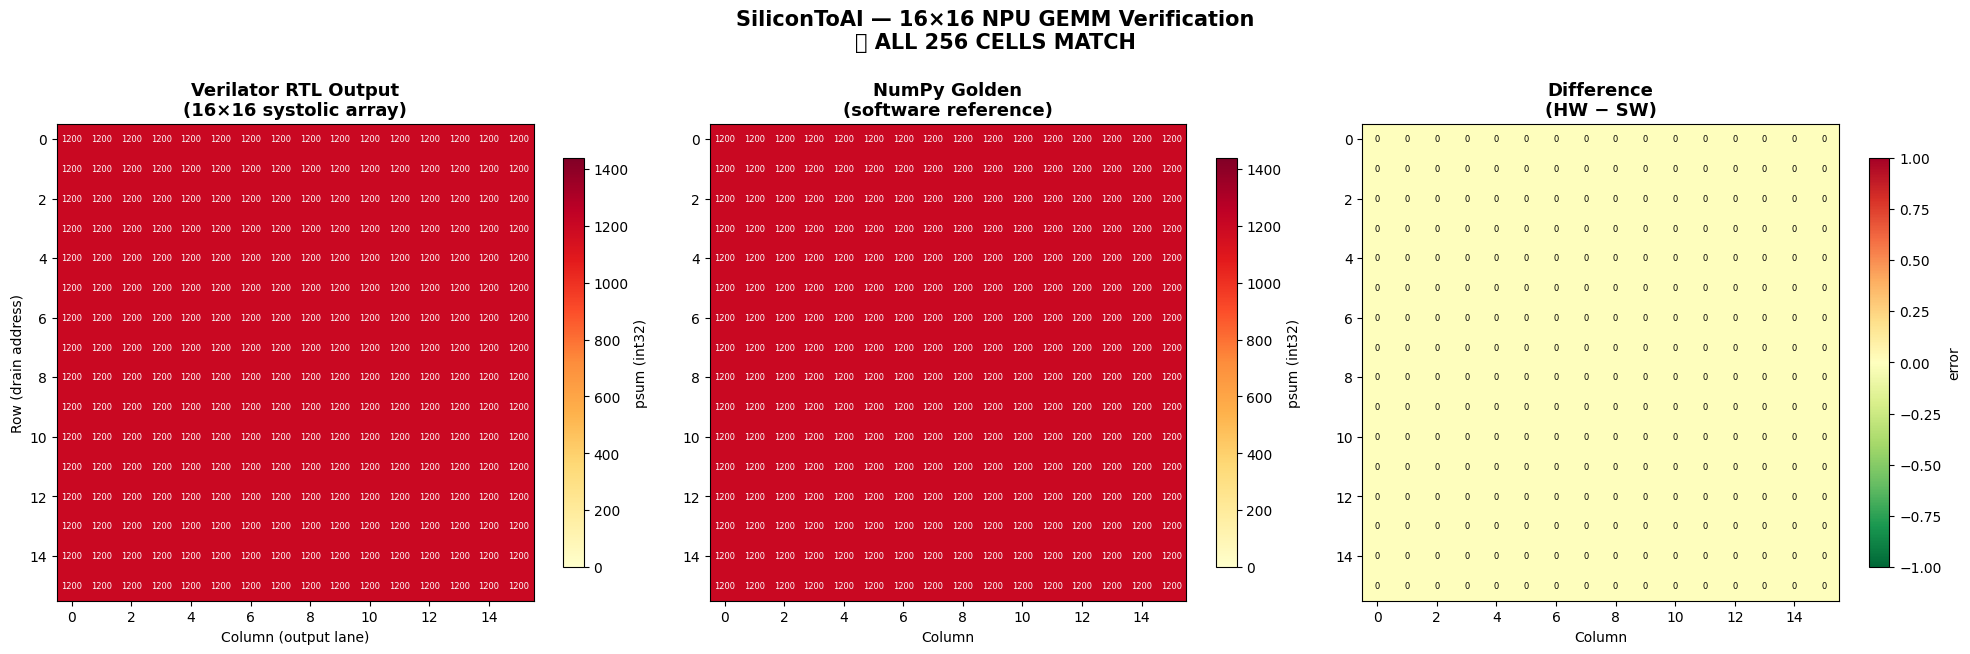

Saved to docs/npu_gemm_heatmap.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
EXPECTED = 1200
vmax = max(EXPECTED * 1.2, hw_matrix.max(), 1)

# --- HW RTL Output ---
im0 = axes[0].imshow(hw_matrix, cmap="YlOrRd", vmin=0, vmax=vmax)
axes[0].set_title("Verilator RTL Output\n(16×16 systolic array)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Column (output lane)")
axes[0].set_ylabel("Row (drain address)")
for i in range(16):
    for j in range(16):
        axes[0].text(j, i, str(hw_matrix[i, j]), ha="center", va="center", fontsize=6,
                     color="white" if hw_matrix[i, j] > EXPECTED * 0.5 else "black")
plt.colorbar(im0, ax=axes[0], shrink=0.8, label="psum (int32)")

# --- NumPy Reference ---
im1 = axes[1].imshow(sw_matrix, cmap="YlOrRd", vmin=0, vmax=vmax)
axes[1].set_title("NumPy Golden\n(software reference)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Column")
for i in range(16):
    for j in range(16):
        axes[1].text(j, i, str(sw_matrix[i, j]), ha="center", va="center", fontsize=6,
                     color="white" if sw_matrix[i, j] > EXPECTED * 0.5 else "black")
plt.colorbar(im1, ax=axes[1], shrink=0.8, label="psum (int32)")

# --- Difference ---
diff = hw_matrix - sw_matrix
abs_max = max(abs(diff.min()), abs(diff.max()), 1)
im2 = axes[2].imshow(diff, cmap="RdYlGn_r", vmin=-abs_max, vmax=abs_max)
axes[2].set_title("Difference\n(HW − SW)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Column")
for i in range(16):
    for j in range(16):
        axes[2].text(j, i, str(diff[i, j]), ha="center", va="center", fontsize=6)
plt.colorbar(im2, ax=axes[2], shrink=0.8, label="error")

match = np.array_equal(hw_matrix, sw_matrix)
status = "✅ ALL 256 CELLS MATCH" if match else f"❌ {np.sum(diff != 0)} MISMATCHES"
fig.suptitle(f"SiliconToAI — 16×16 NPU GEMM Verification\n{status}",
             fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "npu_gemm_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to docs/npu_gemm_heatmap.png")

## 4. Weight-Stationary Systolic Array 내부 동작 시각화

16×16 systolic array에서 데이터가 어떻게 흐르는지 Python으로 재현합니다.

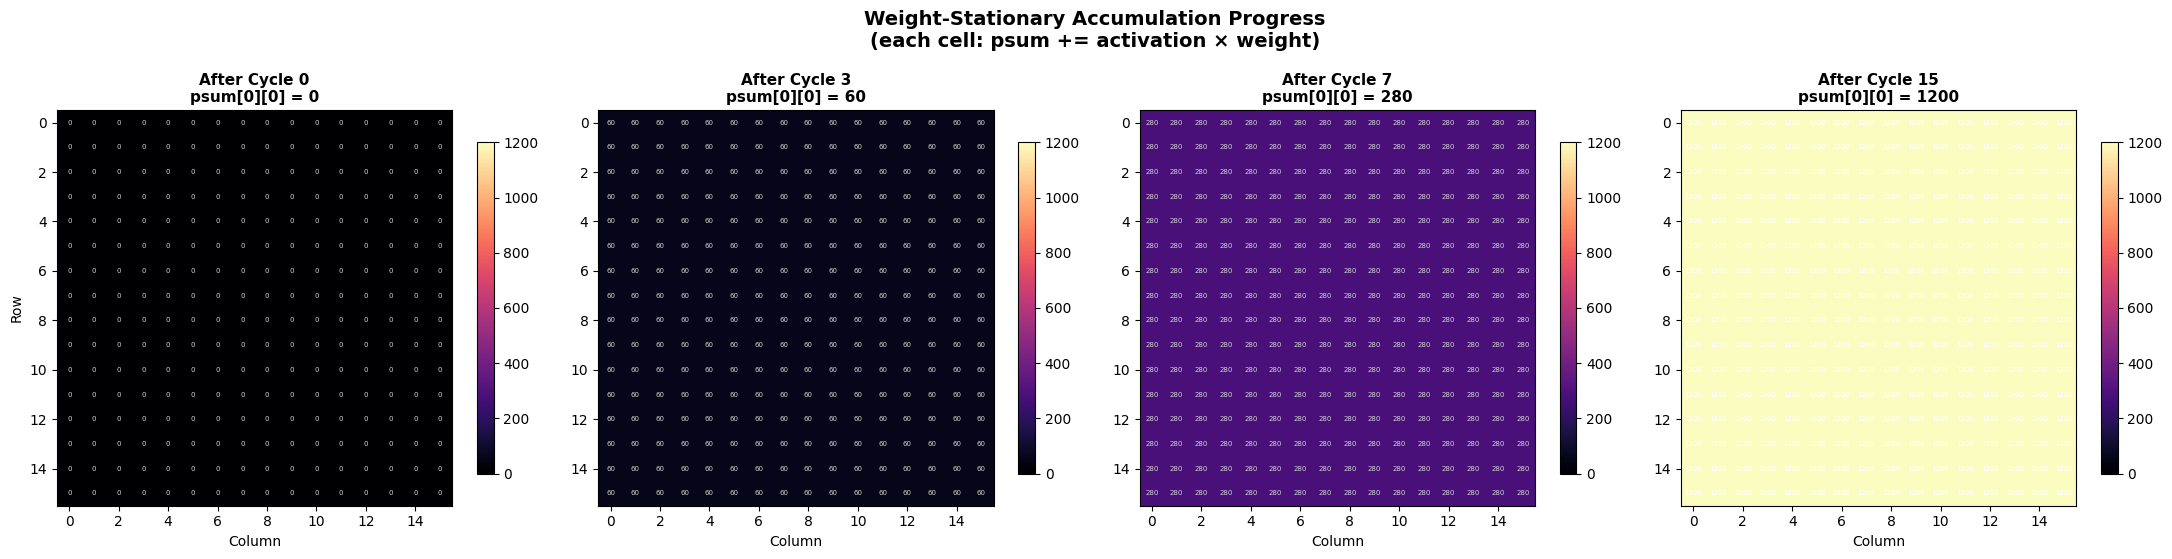

In [5]:
# Simulate weight-stationary dataflow step by step
ROWS, COLS = 16, 16

# PE state
weight_reg = np.zeros((ROWS, COLS), dtype=np.int32)   # stationary weights
psum_acc   = np.zeros((ROWS, COLS), dtype=np.int32)   # accumulators

# Phase 1: Preload weights (weight = 10 for all PEs)
for row in range(ROWS):
    weight_reg[row, :] = 10

# Phase 2: Stream activations with systolic skew
# act_in[col] enters at cycle (col) due to deskew
# After deskew: all columns receive act[k] simultaneously at their local time
#
# In weight-stationary: psum flows DOWN through rows
# At each cycle k (0..15):
#   act[k] = k (lane index pattern)
#   Each PE computes: psum_out = psum_in + act[k] * weight_reg

cycle_snapshots = []
for k in range(ROWS):  # 16 activation rows
    act_val = k  # activation value for this cycle
    for row in range(ROWS):
        for col in range(COLS):
            psum_acc[row, col] += act_val * weight_reg[row, col]
    if k in [0, 3, 7, 15]:  # snapshot at key cycles
        cycle_snapshots.append((k, psum_acc.copy()))

# Plot accumulation progress
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for idx, (cycle, snap) in enumerate(cycle_snapshots):
    im = axes[idx].imshow(snap, cmap="magma", vmin=0, vmax=1200)
    axes[idx].set_title(f"After Cycle {cycle}\npsum[0][0] = {snap[0,0]}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Column")
    if idx == 0:
        axes[idx].set_ylabel("Row")
    for i in range(16):
        for j in range(16):
            axes[idx].text(j, i, str(snap[i, j]), ha="center", va="center",
                          fontsize=5, color="white" if snap[i, j] > 600 else "lightgray")
    plt.colorbar(im, ax=axes[idx], shrink=0.8)

fig.suptitle("Weight-Stationary Accumulation Progress\n"
             "(each cell: psum += activation × weight)",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "npu_accumulation_progress.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Systolic Array Pipeline Timing Diagram

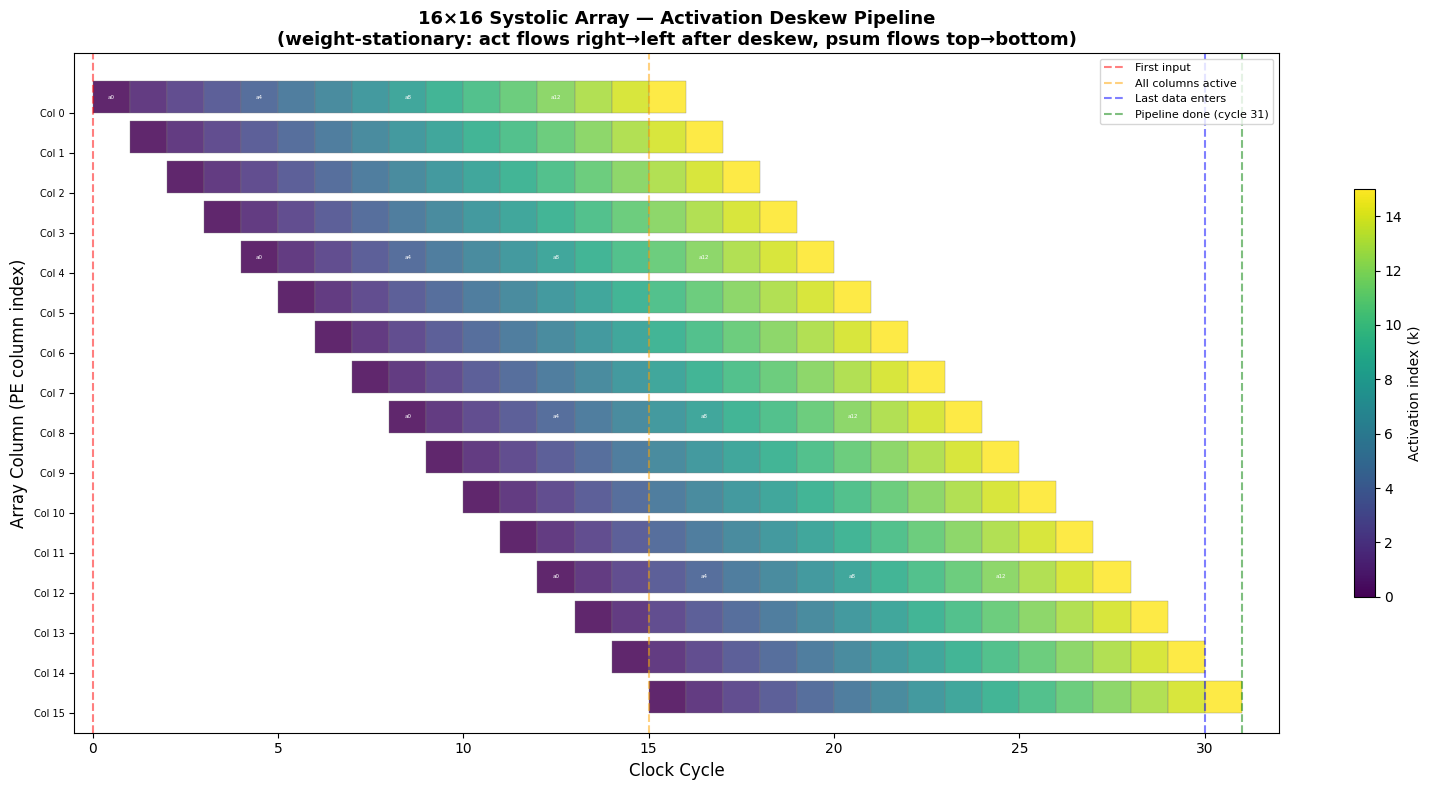

In [6]:
# Visualize the deskew/skew pipeline timing
fig, ax = plt.subplots(figsize=(16, 8))

N = 16
PIPELINE_DEPTH = 31  # total cycles from first input to last output

# Color map for activation index
cmap = plt.cm.viridis

# Draw pipeline timeline
for col in range(N):
    for k in range(N):  # activation index
        # Due to deskew: act[k] enters column 'col' at cycle (k + col)
        # Passes through all 16 rows: exits at cycle (k + col + N - 1)
        entry_cycle = k + col
        # Draw a bar showing when this activation is in the array for this column
        rect = plt.Rectangle(
            (entry_cycle, N - 1 - col), 1, 0.8,
            facecolor=cmap(k / (N - 1)), edgecolor="gray", linewidth=0.3, alpha=0.85
        )
        ax.add_patch(rect)
        if N <= 8 or (col % 4 == 0 and k % 4 == 0):
            ax.text(entry_cycle + 0.5, N - 1 - col + 0.4, f"a{k}",
                   ha="center", va="center", fontsize=4, color="white")

# Annotations
ax.axvline(x=0, color="red", linestyle="--", alpha=0.5, label="First input")
ax.axvline(x=N - 1, color="orange", linestyle="--", alpha=0.5, label="All columns active")
ax.axvline(x=2 * N - 2, color="blue", linestyle="--", alpha=0.5, label="Last data enters")
ax.axvline(x=PIPELINE_DEPTH, color="green", linestyle="--", alpha=0.5, label=f"Pipeline done (cycle {PIPELINE_DEPTH})")

ax.set_xlim(-0.5, PIPELINE_DEPTH + 1)
ax.set_ylim(-0.5, N + 0.5)
ax.set_xlabel("Clock Cycle", fontsize=12)
ax.set_ylabel("Array Column (PE column index)", fontsize=12)
ax.set_yticks(range(N))
ax.set_yticklabels([f"Col {N-1-i}" for i in range(N)], fontsize=7)
ax.set_title("16×16 Systolic Array — Activation Deskew Pipeline\n"
             "(weight-stationary: act flows right→left after deskew, psum flows top→bottom)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)

# Colorbar for activation index
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, N-1))
plt.colorbar(sm, ax=ax, label="Activation index (k)", shrink=0.6)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "npu_pipeline_timing.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. FPGA Resource Utilization Summary

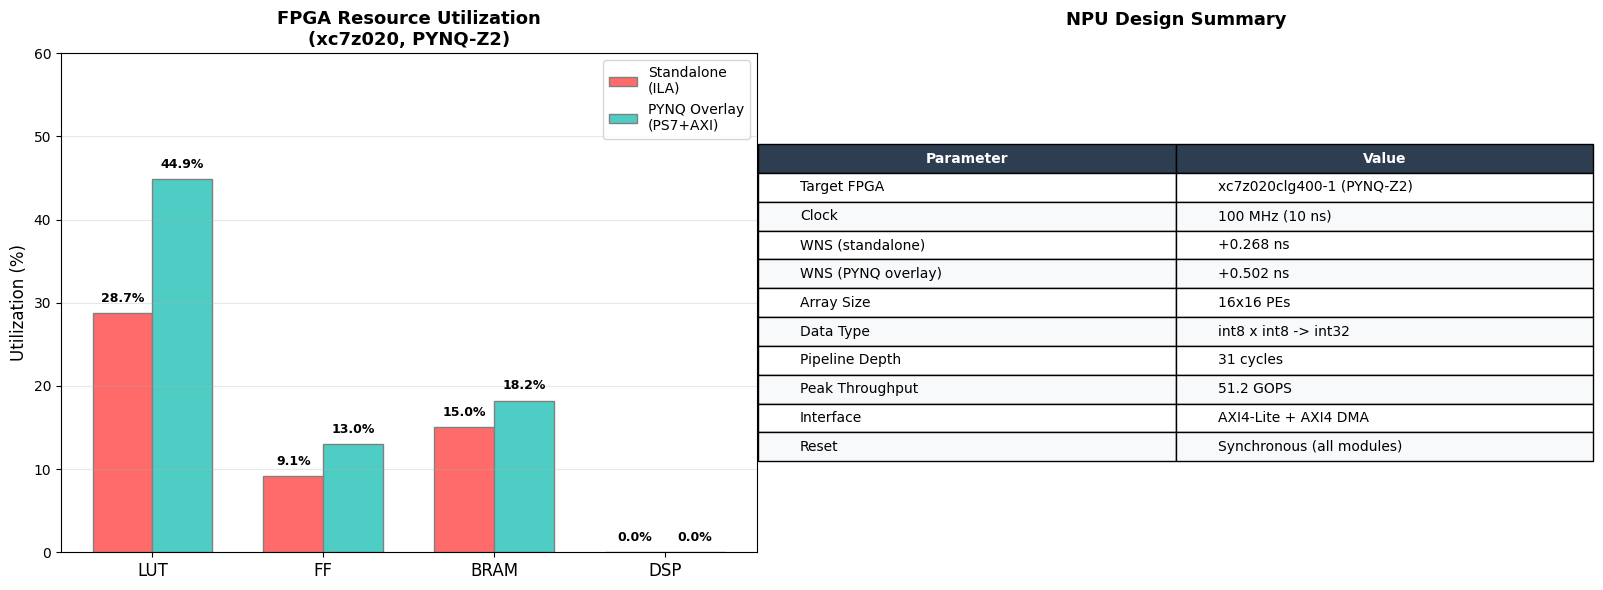

In [9]:
# Parse Vivado utilization report
util_data = {
    "Standalone\n(ILA)": {
        "LUT": (15286, 53200), "FF": (9710, 106400),
        "BRAM": (21, 140), "DSP": (0, 220)
    },
    "PYNQ Overlay\n(PS7+AXI)": {
        "LUT": (23878, 53200), "FF": (13814, 106400),
        "BRAM": (25.5, 140), "DSP": (0, 220)
    },
}

resources = ["LUT", "FF", "BRAM", "DSP"]
x = np.arange(len(resources))
width = 0.35
colors = ["#FF6B6B", "#4ECDC4"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart: utilization % ---
for idx, (label, data) in enumerate(util_data.items()):
    pcts = [data[r][0] / data[r][1] * 100 for r in resources]
    bars = ax1.bar(x + idx * width, pcts, width, label=label, color=colors[idx], edgecolor="gray")
    for bar, pct in zip(bars, pcts):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_xticks(x + width / 2)
ax1.set_xticklabels(resources, fontsize=12)
ax1.set_ylabel("Utilization (%)", fontsize=12)
ax1.set_ylim(0, 60)
ax1.set_title("FPGA Resource Utilization\n(xc7z020, PYNQ-Z2)", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(axis="y", alpha=0.3)

# --- Timing & Area summary table ---
table_data = [
    ["Target FPGA", "xc7z020clg400-1 (PYNQ-Z2)"],
    ["Clock", "100 MHz (10 ns)"],
    ["WNS (standalone)", "+0.268 ns"],
    ["WNS (PYNQ overlay)", "+0.502 ns"],
    ["Array Size", "16x16 PEs"],
    ["Data Type", "int8 x int8 -> int32"],
    ["Pipeline Depth", "31 cycles"],
    ["Peak Throughput", "51.2 GOPS"],
    ["Interface", "AXI4-Lite + AXI4 DMA"],
    ["Reset", "Synchronous (all modules)"],
]

ax2.axis("off")
table = ax2.table(cellText=table_data, colLabels=["Parameter", "Value"],
                  loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F8F9FA")
ax2.set_title("NPU Design Summary", fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "npu_fpga_utilization.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Architecture Block Diagram

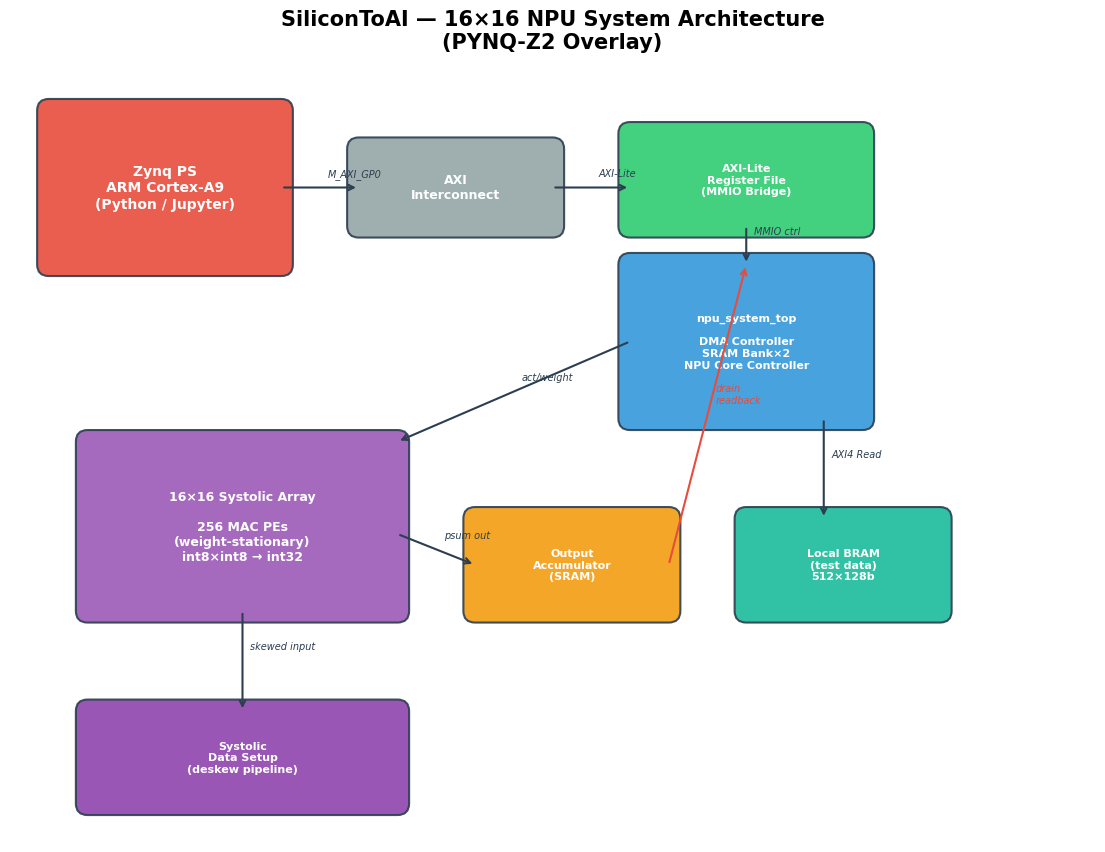

In [7]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")

def draw_box(ax, x, y, w, h, label, color="#3498DB", fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                                    facecolor=color, edgecolor="#2C3E50", linewidth=1.5, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color="white")

def draw_arrow(ax, x1, y1, x2, y2, label="", color="#2C3E50"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.1, my + 0.15, label, fontsize=7, color=color, style="italic")

# PS side
draw_box(ax, 0.5, 7.5, 3, 2, "Zynq PS\nARM Cortex-A9\n(Python / Jupyter)", "#E74C3C", 10)

# AXI Interconnect
draw_box(ax, 4.5, 8, 2.5, 1, "AXI\nInterconnect", "#95A5A6", 9)

# PL modules
draw_box(ax, 8, 8, 3, 1.2, "AXI-Lite\nRegister File\n(MMIO Bridge)", "#2ECC71", 8)

draw_box(ax, 8, 5.5, 3, 2, "npu_system_top\n\nDMA Controller\nSRAM Bank×2\nNPU Core Controller", "#3498DB", 8)

draw_box(ax, 1, 3, 4, 2.2, "16×16 Systolic Array\n\n256 MAC PEs\n(weight-stationary)\nint8×int8 → int32", "#9B59B6", 9)

draw_box(ax, 6, 3, 2.5, 1.2, "Output\nAccumulator\n(SRAM)", "#F39C12", 8)

draw_box(ax, 9.5, 3, 2.5, 1.2, "Local BRAM\n(test data)\n512×128b", "#1ABC9C", 8)

draw_box(ax, 1, 0.5, 4, 1.2, "Systolic\nData Setup\n(deskew pipeline)", "#8E44AD", 8)

# Arrows
draw_arrow(ax, 3.5, 8.5, 4.5, 8.5, "M_AXI_GP0")
draw_arrow(ax, 7, 8.5, 8, 8.5, "AXI-Lite")
draw_arrow(ax, 9.5, 8, 9.5, 7.5, "MMIO ctrl")
draw_arrow(ax, 10.5, 5.5, 10.5, 4.2, "AXI4 Read")
draw_arrow(ax, 8, 6.5, 5, 5.2, "act/weight")
draw_arrow(ax, 3, 3, 3, 1.7, "skewed input")
draw_arrow(ax, 5, 4, 6, 3.6, "psum out")
draw_arrow(ax, 8.5, 3.6, 9.5, 7.5, "drain\nreadback", "#E74C3C")

ax.set_title("SiliconToAI — 16×16 NPU System Architecture\n(PYNQ-Z2 Overlay)",
             fontsize=15, fontweight="bold", y=1.02)

plt.savefig(PROJECT_ROOT / "docs" / "npu_architecture.png", dpi=150, bbox_inches="tight")
plt.show()

---

### 결과 요약

| 시각화 | 파일 | 설명 |
|---|---|---|
| GEMM Heatmap | `docs/npu_gemm_heatmap.png` | HW vs SW 비교 (16×16) |
| Accumulation | `docs/npu_accumulation_progress.png` | 사이클별 누적 과정 |
| Pipeline | `docs/npu_pipeline_timing.png` | Deskew 타이밍 다이어그램 |
| Utilization | `docs/npu_fpga_utilization.png` | FPGA 리소스 + 사양 |
| Architecture | `docs/npu_architecture.png` | 시스템 블록 다이어그램 |